# 3DGS moderno · Mitad 2 — Entrenamiento con `gsplat`

> ✅ **Validado end-to-end en RTX 5070 (sm_120)** con `torch 2.11.0+cu128` +
> `gsplat 1.5.3`. Requiere GPU; instalación abajo. La pérdida L1 baja de ~0.16 a
> ~0.03 y la reconstrucción reproduce la arcada (§4).

Toma el paquete que generó el [notebook 03](03-synthetic-views-for-3dgs.ipynb)
(`images/` + `transforms.json` + `init.ply`) y **entrena** un campo de gaussianas
3D optimizándolas contra las vistas (pérdida fotométrica) — esto **sí** es 3DGS
moderno (gaussianas anisótropas, color, opacidad, optimización diferenciable).

**Instalación (una vez):**
```bash
uv pip install torch --index-url https://download.pytorch.org/whl/cu128   # Blackwell
uv pip install gsplat
```

**Alcance:** validación del motor con verdad-terreno (reconstruir la malla desde
sus vistas). Ver [`docs/research/dataset-teeth3ds.md` §5.1](../docs/research/dataset-teeth3ds.md).

## 0 · Verificar GPU + gsplat

In [1]:
import torch
print("torch:", torch.__version__)
assert torch.cuda.is_available(), "sin CUDA — se necesita GPU"
dev = torch.device("cuda")
print("GPU:", torch.cuda.get_device_name(0))
cc = torch.cuda.get_device_capability(0)
print(f"capacidad de cómputo: sm_{cc[0]}{cc[1]}")  # RTX 5070 -> sm_120

import gsplat
from gsplat import rasterization
print("gsplat:", gsplat.__version__)

torch: 2.11.0+cu128
GPU: NVIDIA GeForce RTX 5070
capacidad de cómputo: sm_120
gsplat: 1.5.3


## 1 · Cargar el paquete del notebook 03

In [2]:
import json
from pathlib import Path
import numpy as np
import vtk
from vtk.util.numpy_support import vtk_to_numpy

ROOT = Path.cwd()
while ROOT != ROOT.parent and not (ROOT / "data" / "processed").exists():
    ROOT = ROOT.parent

# localizar el caso generado por el 03
cases = sorted((ROOT / "data/processed/teeth3ds").glob("*_3dgs"))
assert cases, "No hay paquete 3dgs — corre antes el notebook 03"
CASE = cases[0]
print("caso:", CASE.name)

meta = json.loads((CASE / "transforms.json").read_text())
W, H = meta["w"], meta["h"]
fx, fy, cx, cy = meta["fl_x"], meta["fl_y"], meta["cx"], meta["cy"]
K = torch.tensor([[fx, 0, cx], [0, fy, cy], [0, 0, 1]], dtype=torch.float32)


def load_png(path):
    r = vtk.vtkPNGReader(); r.SetFileName(str(path)); r.Update()
    img = r.GetOutput(); dim = img.GetDimensions()
    arr = vtk_to_numpy(img.GetPointData().GetScalars()).reshape(dim[1], dim[0], -1)
    return arr[::-1, :, :3].astype(np.float32) / 255.0  # flip Y, RGB, [0,1]


gt_imgs, c2ws = [], []
for fr in meta["frames"]:
    gt_imgs.append(load_png(CASE / fr["file_path"]))
    c2ws.append(np.array(fr["transform_matrix"], dtype=np.float32))
gt = torch.from_numpy(np.stack(gt_imgs)).to(dev)          # [C,H,W,3]
c2w = torch.from_numpy(np.stack(c2ws)).to(dev)            # [C,4,4] OpenGL

# OpenGL (x der, y arr, z atrás) -> OpenCV (x der, y abajo, z delante)
flip = torch.diag(torch.tensor([1., -1., -1., 1.], device=dev))
c2w_cv = c2w @ flip
viewmats = torch.linalg.inv(c2w_cv)                      # world->cam [C,4,4]
Ks = K.to(dev).unsqueeze(0).repeat(len(meta["frames"]), 1, 1)  # [C,3,3]
print(f"{gt.shape[0]} vistas · {W}x{H} · K fx={fx:.0f}")

caso: 01A6GW4A_lower_3dgs


24 vistas · 400x400 · K fx=746


## 2 · Inicializar las gaussianas desde `init.ply`

Cada punto de la nube → una gaussiana. Parámetros optimizables: posición, escala (log), rotación (cuaternión), opacidad (logit) y color (logit RGB).

In [3]:
pr = vtk.vtkPLYReader(); pr.SetFileName(str(CASE / "init.ply")); pr.Update()
init_pts = vtk_to_numpy(pr.GetOutput().GetPoints().GetData()).astype(np.float32)
N = len(init_pts)
means = torch.nn.Parameter(torch.from_numpy(init_pts).to(dev))

extent = float(np.linalg.norm(init_pts.max(0) - init_pts.min(0)))
init_scale = extent * 0.005
scales = torch.nn.Parameter(torch.full((N, 3), np.log(init_scale), device=dev))
quats = torch.nn.Parameter(torch.tensor([1., 0, 0, 0], device=dev).repeat(N, 1))
opacities = torch.nn.Parameter(torch.full((N,), float(np.log(0.1 / 0.9)), device=dev))  # logit(0.1)
colors = torch.nn.Parameter(torch.zeros((N, 3), device=dev))  # sigmoid(0)=0.5 gris

print(f"{N:,} gaussianas · escala inicial {init_scale:.3f} mm")

opt = torch.optim.Adam([
    {"params": [means],     "lr": 1.6e-4 * extent},
    {"params": [scales],    "lr": 5e-3},
    {"params": [quats],     "lr": 1e-3},
    {"params": [opacities], "lr": 5e-2},
    {"params": [colors],    "lr": 2.5e-3},
])

36,664 gaussianas · escala inicial 0.594 mm


## 3 · Bucle de entrenamiento

En cada paso: elegir una vista, rasterizar las gaussianas a esa cámara, comparar con la foto real (L1), retropropagar y actualizar. *(Sin densificación en esta versión — se parte de una nube densa; la densificación adaptativa es la mejora natural siguiente.)*

In [4]:
import torch.nn.functional as F

ITERS = 1500
for it in range(ITERS):
    cam = torch.randint(0, gt.shape[0], (1,)).item()
    render, alpha, info = rasterization(
        means=means,
        quats=quats / quats.norm(dim=-1, keepdim=True),
        scales=torch.exp(scales),
        opacities=torch.sigmoid(opacities),
        colors=torch.sigmoid(colors),
        viewmats=viewmats[cam:cam + 1],
        Ks=Ks[cam:cam + 1],
        width=W, height=H,
    )
    pred = render[0]                       # [H,W,3]
    loss = F.l1_loss(pred, gt[cam])
    opt.zero_grad(); loss.backward(); opt.step()
    if it % 150 == 0 or it == ITERS - 1:
        print(f"iter {it:4d} · L1 {loss.item():.4f} · gaussianas {means.shape[0]:,}")

iter    0 · L1 0.1637 · gaussianas 36,664


iter  150 · L1 0.1141 · gaussianas 36,664


iter  300 · L1 0.0936 · gaussianas 36,664


iter  450 · L1 0.0745 · gaussianas 36,664


iter  600 · L1 0.0456 · gaussianas 36,664


...

iter  900 · L1 0.0401 · gaussianas 36,664


iter 1050 · L1 0.0327 · gaussianas 36,664


iter 1200 · L1 0.0350 · gaussianas 36,664


iter 1350 · L1 0.0329 · gaussianas 36,664


iter 1499 · L1 0.0307 · gaussianas 36,664


## 4 · Comparar: 3DGS entrenado vs. vista real

izquierda: foto real  |  derecha: 3DGS entrenado


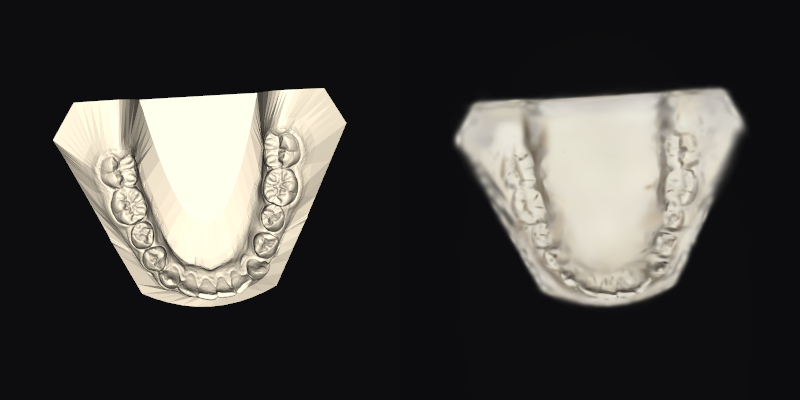

In [5]:
from IPython.display import display
import numpy as np

cam = 0
with torch.no_grad():
    render, _, _ = rasterization(
        means=means, quats=quats / quats.norm(dim=-1, keepdim=True),
        scales=torch.exp(scales), opacities=torch.sigmoid(opacities),
        colors=torch.sigmoid(colors), viewmats=viewmats[cam:cam + 1],
        Ks=Ks[cam:cam + 1], width=W, height=H,
    )
pred = (render[0].clamp(0, 1).cpu().numpy() * 255).astype(np.uint8)
real = (gt[cam].cpu().numpy() * 255).astype(np.uint8)
side = np.concatenate([real, pred], axis=1)  # real | 3DGS

import vtk
from vtk.util.numpy_support import numpy_to_vtk
img = vtk.vtkImageData(); img.SetDimensions(side.shape[1], side.shape[0], 1)
va = numpy_to_vtk(side[::-1].reshape(-1, 3), deep=True); va.SetNumberOfComponents(3)
img.GetPointData().SetScalars(va)
out = CASE / "compare_real_vs_3dgs.png"
w = vtk.vtkPNGWriter(); w.SetFileName(str(out)); w.SetInputData(img); w.Write()
from IPython.display import Image
print("izquierda: foto real  |  derecha: 3DGS entrenado")
display(Image(filename=str(out)))

## 5 · Exportar + serializar al contrato

Guardamos el campo entrenado (`.ply`) y lo referenciamos por hash desde un `TwinSnapshot`, igual que el PoC 01 — cierra el círculo con la arquitectura.

In [6]:
import sys, hashlib
from datetime import datetime, timezone

# .ply del campo entrenado (posición + color por gaussiana)
pts_np = means.detach().cpu().numpy()
col_np = (torch.sigmoid(colors).detach().cpu().numpy() * 255).astype(np.uint8)
vpts = vtk.vtkPoints()
for p in pts_np:
    vpts.InsertNextPoint(*p)
pd = vtk.vtkPolyData(); pd.SetPoints(vpts)
carr = numpy_to_vtk(col_np, deep=True); carr.SetName("RGB"); carr.SetNumberOfComponents(3)
pd.GetPointData().SetScalars(carr)
trained = CASE / "trained_3dgs.ply"
w = vtk.vtkPLYWriter(); w.SetFileName(str(trained)); w.SetInputData(pd)
w.SetArrayName("RGB"); w.SetFileTypeToBinary(); w.Write()
digest = hashlib.sha256(trained.read_bytes()).hexdigest()[:16]
print("campo entrenado:", trained.name, "· sha256", digest, "·", len(pts_np), "gaussianas")

sys.path.insert(0, str(ROOT / "packages/core-schemas/src"))
from core_schemas import Modality, Provenance, TwinSnapshot

snap = TwinSnapshot(
    acquisition_id=f"{CASE.name}_trained",
    timestamp=datetime.now(timezone.utc),
    modalities=[Modality.STL],
    gaussian_field_ref=f"ply://{trained.name}#sha256:{digest}",
    n_primitives=len(pts_np),
    provenance=Provenance(source_file=str(CASE.name), modality=Modality.STL,
                          agent="gsplat-3dgs-train", confidence=0.5),
)
print(snap.model_dump_json(indent=2))

campo entrenado: trained_3dgs.ply · sha256 583a1d9b4c1b0028 · 36664 gaussianas
{
  "acquisition_id": "01A6GW4A_lower_3dgs_trained",
  "timestamp": "2026-07-16T11:27:42.307253Z",
  "modalities": [
    "stl"
  ],
  "gaussian_field_ref": "ply://trained_3dgs.ply#sha256:583a1d9b4c1b0028",
  "n_primitives": 36664,
  "regional": [],
  "provenance": {
    "source_file": "01A6GW4A_lower_3dgs",
    "modality": "stl",
    "agent": "gsplat-3dgs-train",
    "confidence": 0.5,
    "ingested_at": "2026-07-16T11:27:42.307264Z"
  }
}


## 6 · Conclusiones (insumo del ADR 002)

Al ejecutarse, este notebook cierra el **3DGS moderno de extremo a extremo**:
malla → vistas+poses (03) → **gaussianas entrenadas** (04) → contrato + `.ply`.

- Si la reconstrucción (§4, derecha) se parece a la foto real (§4, izquierda), el
  motor **funciona** con datos dentales → evidencia fuerte para **D1 / ADR 002**.
- **Mejoras naturales:** densificación/poda adaptativa (`gsplat` `DefaultStrategy`),
  color por armónicos esféricos, más vistas, métricas PSNR/SSIM contra la malla.
- **Export web:** el `.ply` de gaussianas alimenta el visor three.js/GaussianSplats3D
  de la **Issue 3**.